<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/09_image_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09 — Image Augmentation & Classification

## What This Notebook Covers
This notebook covers image-specific augmentation techniques using three
complementary libraries, then trains a classifier with and without
augmentation to measure the real impact on test accuracy.

**Libraries used:**
- `tf.keras.layers` — lightweight augmentation baked into the model graph
- `albumentations` — the most widely used augmentation library in competitions
- `AugLy` (Facebook Research) — augmentation with realistic distortions

**Techniques covered:**
- Geometric: flip, rotate, shift, shear, perspective, elastic transform
- Colour: brightness, contrast, hue-saturation, CLAHE, channel shuffle
- Noise & blur: Gaussian noise, motion blur, ISO noise, JPEG compression
- Erasing: Cutout, CoarseDropout, GridDistortion
- Composition: `A.Compose`, `A.OneOf`, probability control per transform
- AugLy: overlays, emoji, text, perspective warp, encoding artifacts
- Full A/B test: baseline classifier vs augmented classifier

**Dataset:** CIFAR-10


In [1]:
!pip install albumentations augly --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('albumentations:', A.__version__)
print('Device        :', device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 48.8 MB/s eta 0:00:00
albumentations: 2.0.8
Device        : cuda


## 1. Load CIFAR-10


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

X_valid, y_valid = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train : {X_train.shape} uint8')
print(f'Valid : {X_valid.shape}')
print(f'Test  : {X_test.shape}')
print('Pixel range:', X_train.min(), '-', X_train.max())
print('Note: albumentations expects uint8 [0,255] images')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train : (45000, 32, 32, 3) uint8
Valid : (5000, 32, 32, 3)
Test  : (10000, 32, 32, 3)
Pixel range: 0 - 255
Note: albumentations expects uint8 [0,255] images


## 2. Albumentations — Core Concepts

Albumentations is the gold standard for image augmentation in practice.
Key concepts:

- `A.Compose([...])` — chain multiple transforms
- `p=0.5` argument on each transform — probability of applying it
- `A.OneOf([...], p=1.0)` — randomly pick ONE transform from a list
- Input/output: numpy uint8 arrays, always pass as keyword: `transform(image=img)`
- Returns a dict: `result['image']` gives the augmented image

Unlike Keras layers, albumentations runs on CPU in numpy.
For training, use it inside a PyTorch `Dataset.__getitem__` or a
tf.data `map` with `tf.py_function`.


In [3]:
def show_albumentations(transform, images, n=8, title='Albumentations preview'):
    """
    Apply an albumentations transform to n images and display before/after.
    images: uint8 numpy array (N, H, W, C)
    """
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(images[i])
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=9)

        result = transform(image=images[i])   # albumentations API
        axes[1, i].imshow(result['image'])
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Augmented', fontsize=9)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

print('Helper defined.')

Helper defined.


## 3. Geometric Transforms


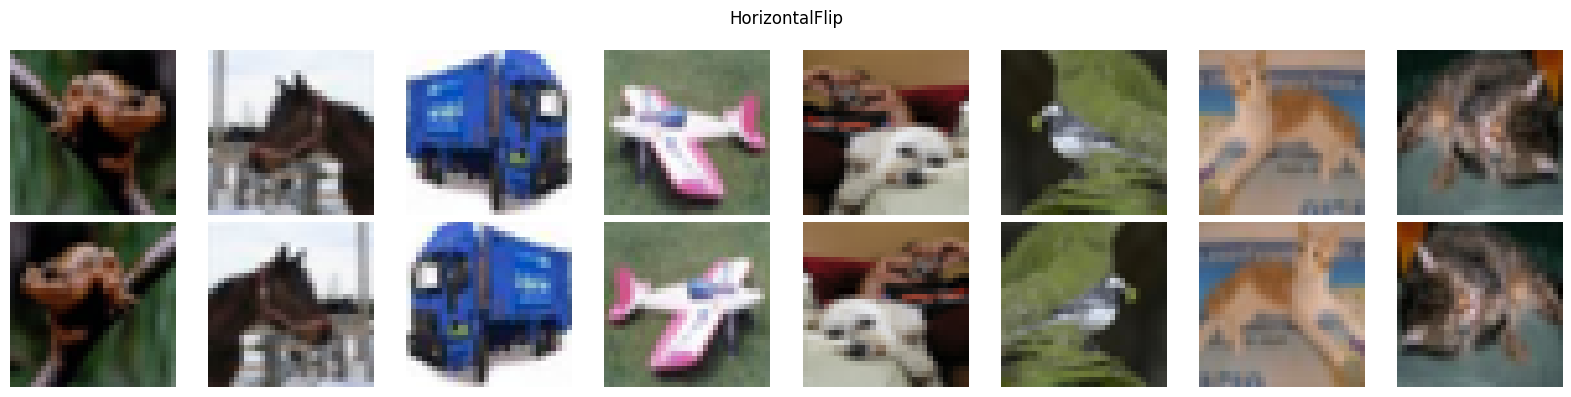

In [4]:
# HorizontalFlip: mirror left-right
# Most useful transform for natural images — cars and animals still look valid flipped
flip_transform = A.Compose([A.HorizontalFlip(p=1.0)])
show_albumentations(flip_transform, X_train, title='HorizontalFlip')

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


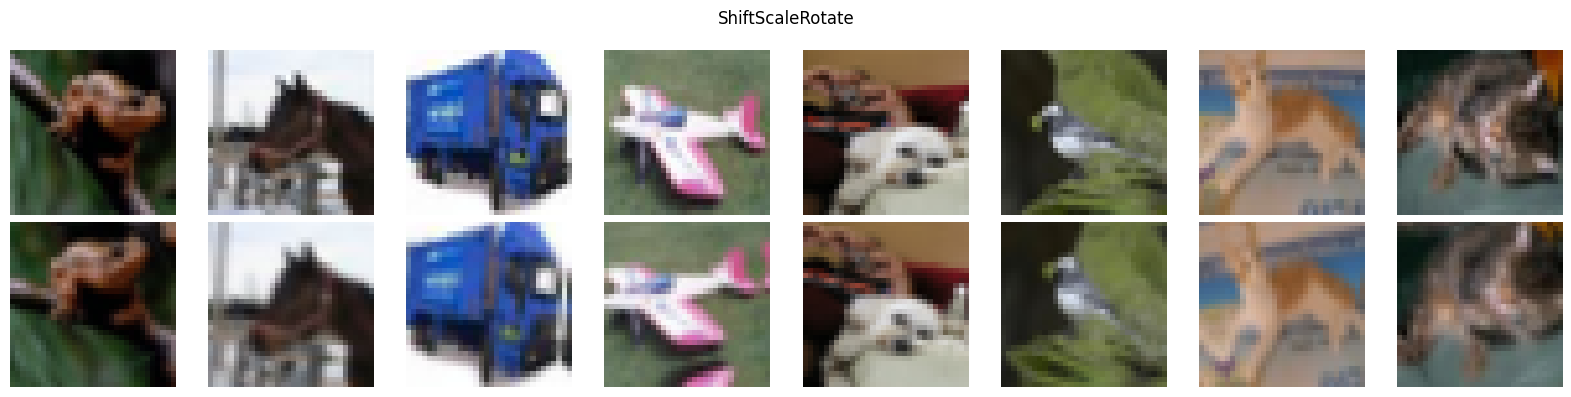

In [5]:
# ShiftScaleRotate: three transforms in one
# shift_limit: max fraction of image to shift
# scale_limit: max zoom change as fraction
# rotate_limit: max rotation in degrees
# border_mode: how to fill pixels outside the image after rotation
ssr = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=30,
        border_mode=cv2.BORDER_REFLECT_101,
        p=1.0
    )
])
show_albumentations(ssr, X_train, title='ShiftScaleRotate')

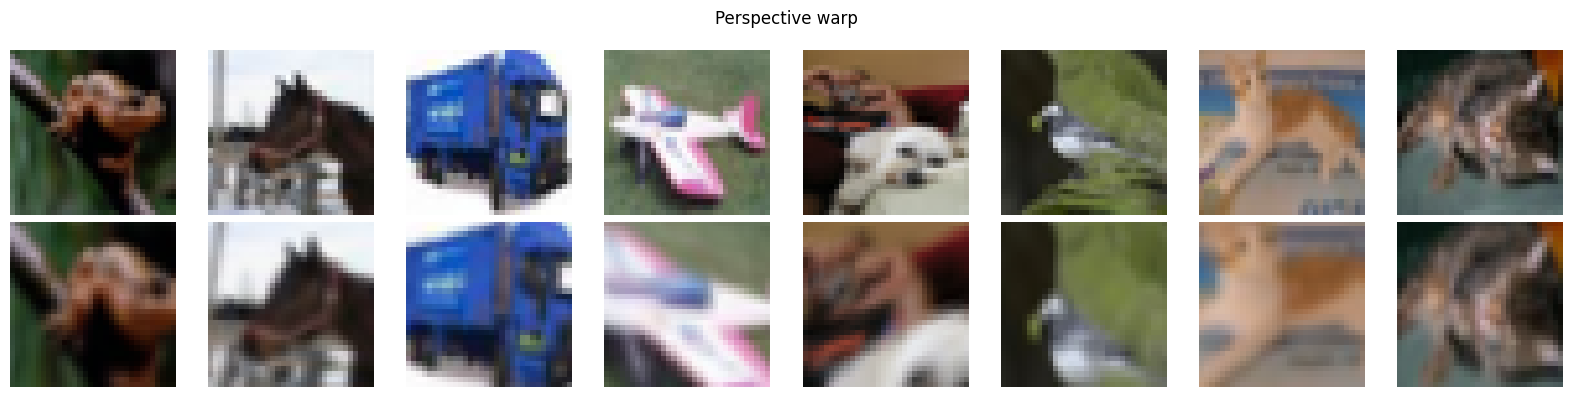

In [6]:
# Perspective: warps the image as if viewed from a different angle
# Good for: documents, text, signs — any task where perspective varies
persp = A.Compose([A.Perspective(scale=(0.05, 0.15), p=1.0)])
show_albumentations(persp, X_train, title='Perspective warp')

/tmp/ipykernel_1352/3550450623.py:5: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=60, sigma=12, alpha_affine=10, p=1.0)


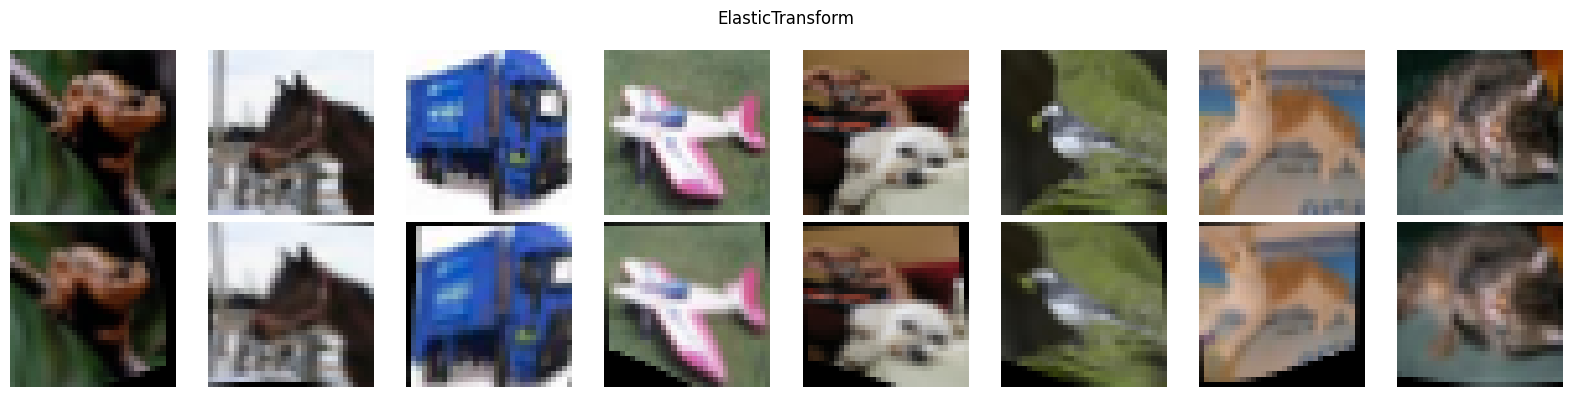

In [7]:
# ElasticTransform: deforms the image with a random displacement field
# Originally designed for medical image augmentation (MRI, histology)
# alpha controls displacement magnitude, sigma controls smoothness
elastic = A.Compose([
    A.ElasticTransform(alpha=60, sigma=12, alpha_affine=10, p=1.0)
])
show_albumentations(elastic, X_train, title='ElasticTransform')

## 4. Colour & Intensity Transforms


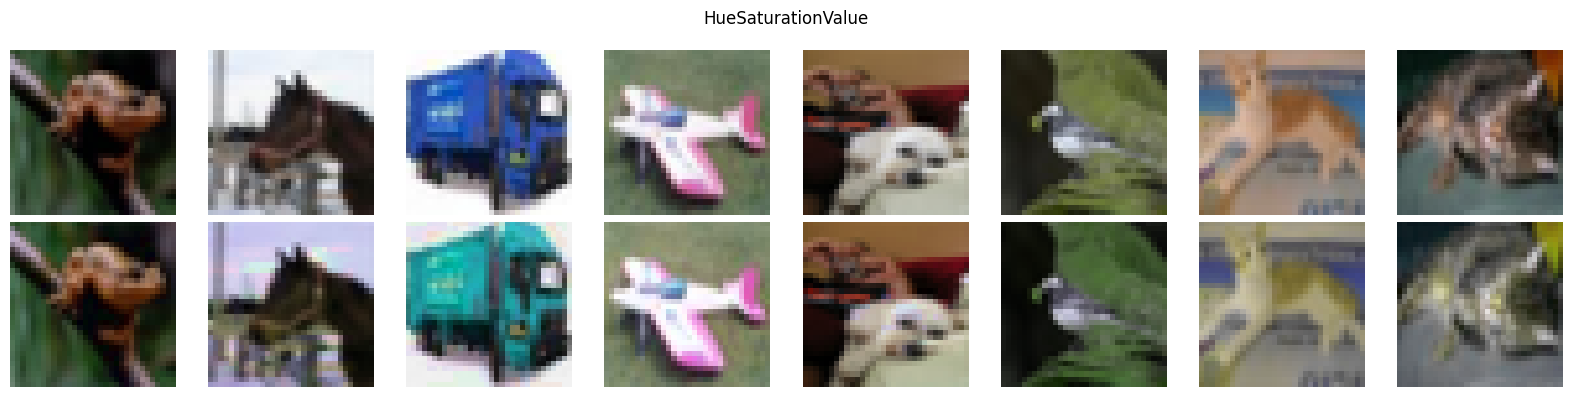

In [8]:
# HueSaturationValue: shift hue, saturation, value independently
# hue_shift_limit: max hue shift in degrees (-180, 180)
# sat_shift_limit: max saturation shift
# val_shift_limit: max brightness shift
hsv = A.Compose([
    A.HueSaturationValue(
        hue_shift_limit=20,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=1.0
    )
])
show_albumentations(hsv, X_train, title='HueSaturationValue')

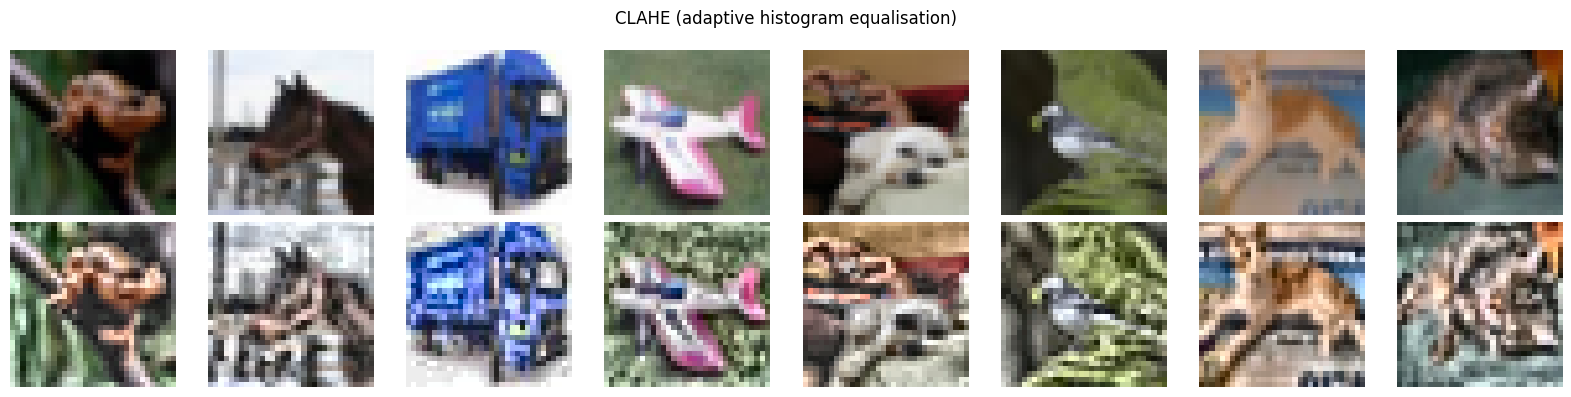

In [9]:
# CLAHE: Contrast Limited Adaptive Histogram Equalization
# Enhances local contrast — particularly useful for medical images and
# low-light photography where global contrast adjustment is insufficient
clahe = A.Compose([A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0)])
show_albumentations(clahe, X_train, title='CLAHE (adaptive histogram equalisation)')

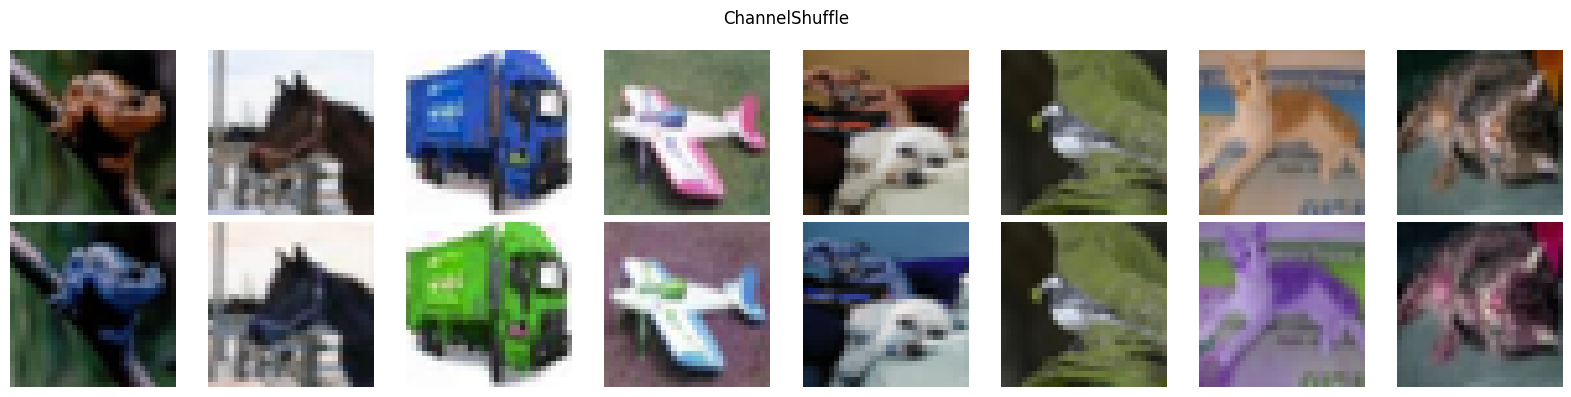

In [10]:
# ChannelShuffle: randomly reorder the RGB channels
# Makes the model invariant to channel ordering — useful when
# the model might encounter BGR vs RGB input inconsistencies
ch_shuffle = A.Compose([A.ChannelShuffle(p=1.0)])
show_albumentations(ch_shuffle, X_train, title='ChannelShuffle')

## 5. Noise & Blur Transforms


/tmp/ipykernel_1352/3862988194.py:3: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  gauss_noise = A.Compose([A.GaussNoise(var_limit=(20, 80), p=1.0)])


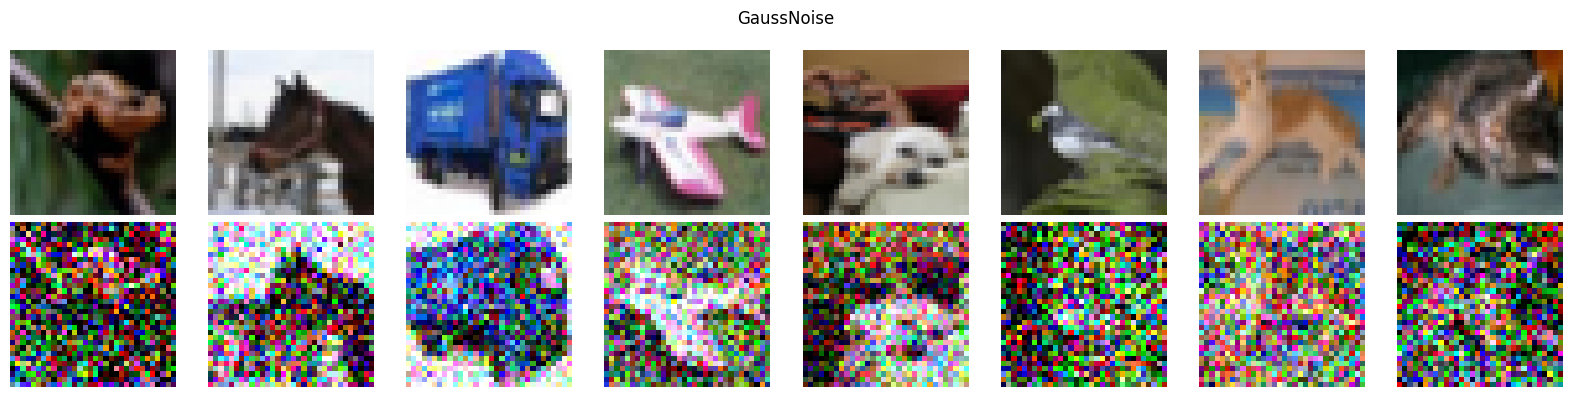

In [11]:
# GaussNoise: adds Gaussian noise to simulate sensor noise
# var_limit: variance range of the noise
gauss_noise = A.Compose([A.GaussNoise(var_limit=(20, 80), p=1.0)])
show_albumentations(gauss_noise, X_train, title='GaussNoise')

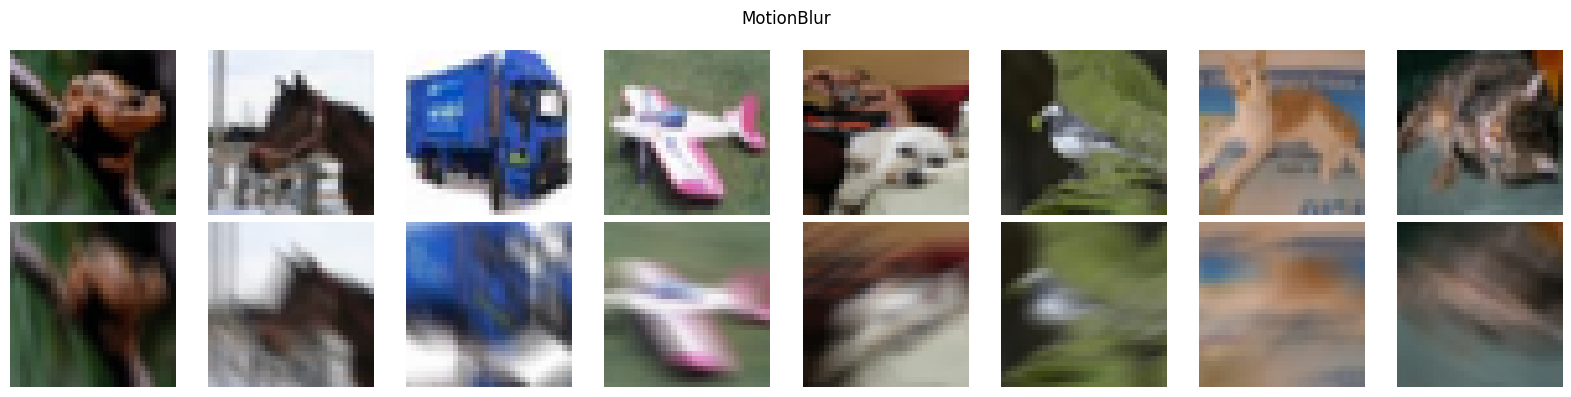

In [12]:
# MotionBlur: simulates camera or object motion during exposure
# blur_limit: maximum kernel size
motion_blur = A.Compose([A.MotionBlur(blur_limit=(7, 15), p=1.0)])
show_albumentations(motion_blur, X_train, title='MotionBlur')

/tmp/ipykernel_1352/2200824282.py:5: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=20, quality_upper=60, p=1.0)


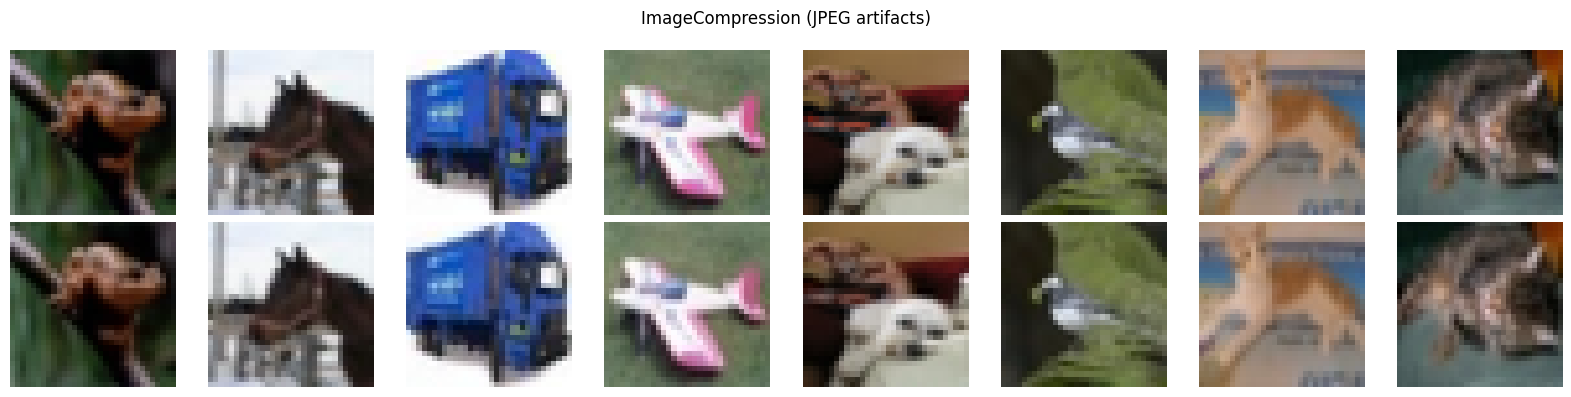

In [13]:
# ImageCompression: simulates JPEG compression artifacts
# quality_lower / quality_upper: JPEG quality range (100 = lossless)
# Useful for models that will be deployed on compressed images
jpeg = A.Compose([
    A.ImageCompression(quality_lower=20, quality_upper=60, p=1.0)
])
show_albumentations(jpeg, X_train, title='ImageCompression (JPEG artifacts)')

## 6. Erasing Transforms


/tmp/ipykernel_1352/3168244268.py:6: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


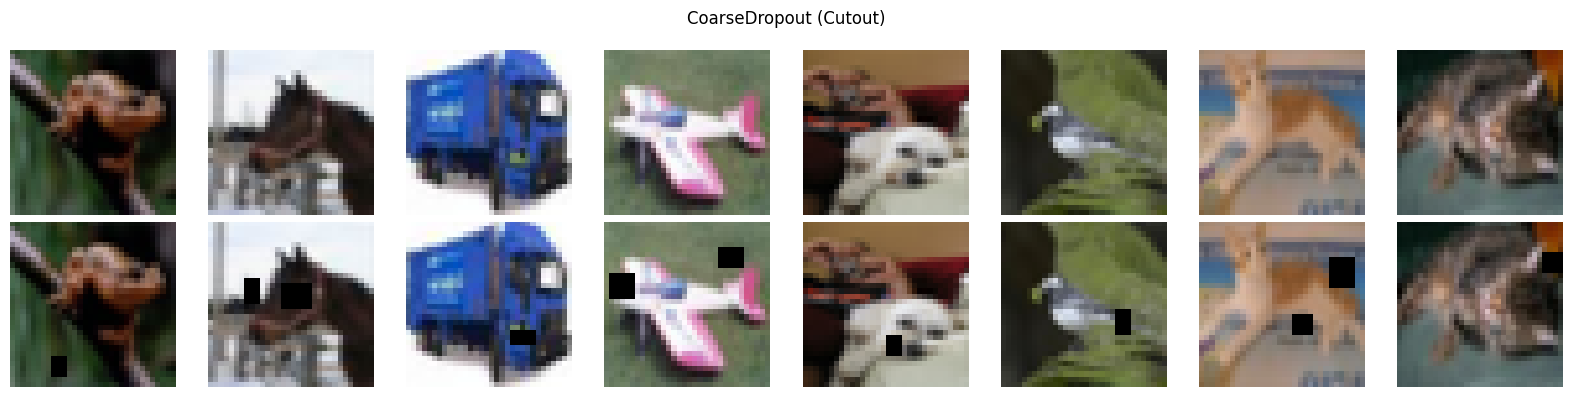

In [14]:
# CoarseDropout: drops rectangular patches and fills with a constant
# Equivalent to Cutout — forces the model to not rely on any single region
# max_holes: maximum number of patches
# max_height / max_width: maximum size of each patch
coarse_drop = A.Compose([
    A.CoarseDropout(
        max_holes=4,
        max_height=10,
        max_width=10,
        min_holes=1,
        fill_value=0,
        p=1.0
    )
])
show_albumentations(coarse_drop, X_train, title='CoarseDropout (Cutout)')

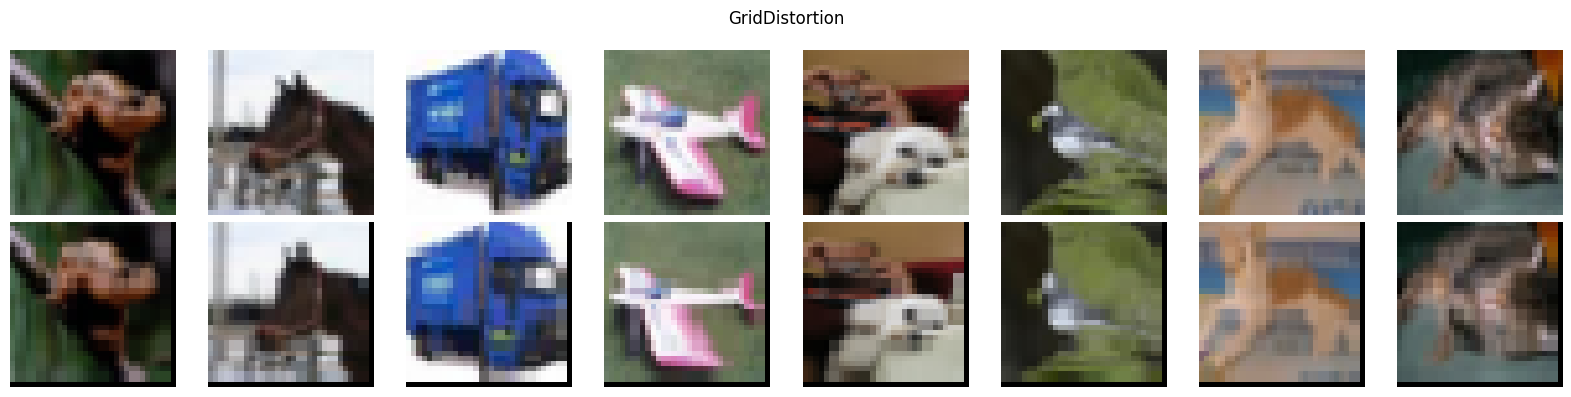

In [15]:
# GridDistortion: applies a grid-based non-linear warp
# Different from ElasticTransform — distortion follows a regular grid
grid_dist = A.Compose([
    A.GridDistortion(num_steps=5, distort_limit=0.4, p=1.0)
])
show_albumentations(grid_dist, X_train, title='GridDistortion')

## 7. Composing a Production Augmentation Pipeline

`A.Compose` chains transforms sequentially. `A.OneOf` picks exactly one
transform from a list at random. The `p` argument on each transform
controls the probability of application independently.

This is the standard recipe for a competition-grade pipeline:
spatial first, then colour, then noise/blur, then erasing.


/tmp/ipykernel_1352/4026659997.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 40)),
/tmp/ipykernel_1352/4026659997.py:20: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=90),
/tmp/ipykernel_1352/4026659997.py:24: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


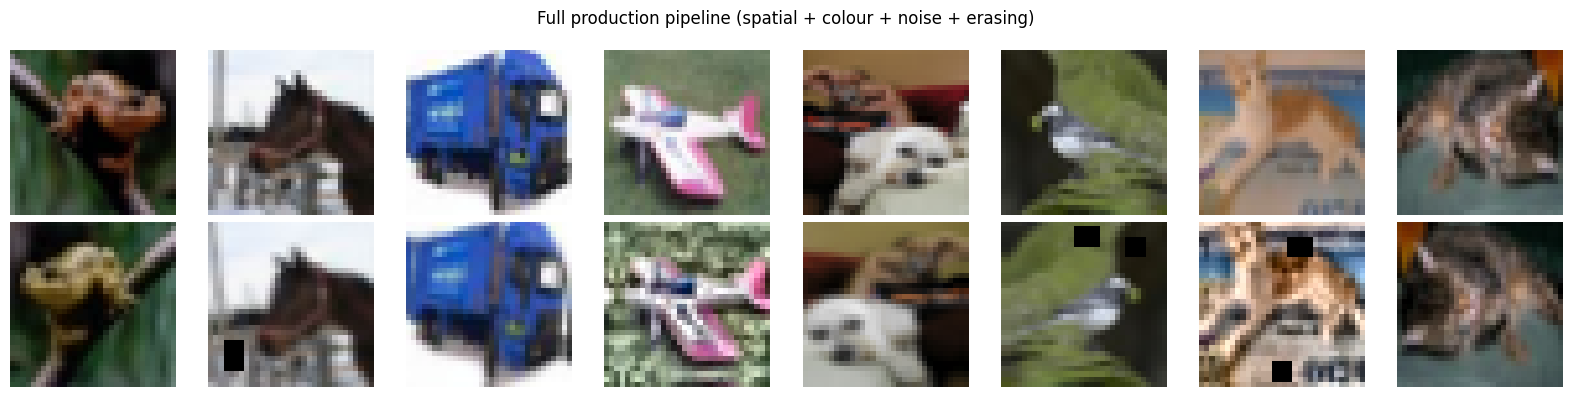

In [16]:
TRAIN_TRANSFORM = A.Compose([
    # --- Spatial ---
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.08, scale_limit=0.1, rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101, p=0.5
    ),

    # --- Colour: pick one of these ---
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
        A.CLAHE(clip_limit=3.0),
    ], p=0.6),

    # --- Noise/Blur: pick one of these ---
    A.OneOf([
        A.GaussNoise(var_limit=(10, 40)),
        A.MotionBlur(blur_limit=5),
        A.ImageCompression(quality_lower=50, quality_upper=90),
    ], p=0.3),

    # --- Erasing ---
    A.CoarseDropout(
        max_holes=2, max_height=8, max_width=8,
        fill_value=0, p=0.3
    ),
])

# Preview the full pipeline
show_albumentations(
    TRAIN_TRANSFORM, X_train,
    title='Full production pipeline (spatial + colour + noise + erasing)'
)

## 8. AugLy — Realistic Social-Media Distortions

AugLy (Facebook Research) focuses on augmentations that simulate
real-world image distortions from social media and messaging apps:
overlays, emoji, memes, screenshot effects, and encoding artifacts.
Particularly useful for training content moderation models.


AugLy available.


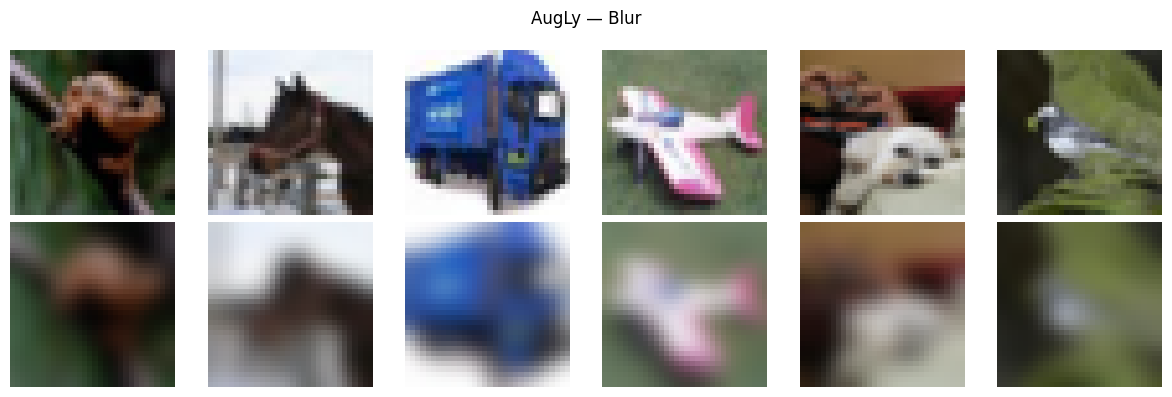

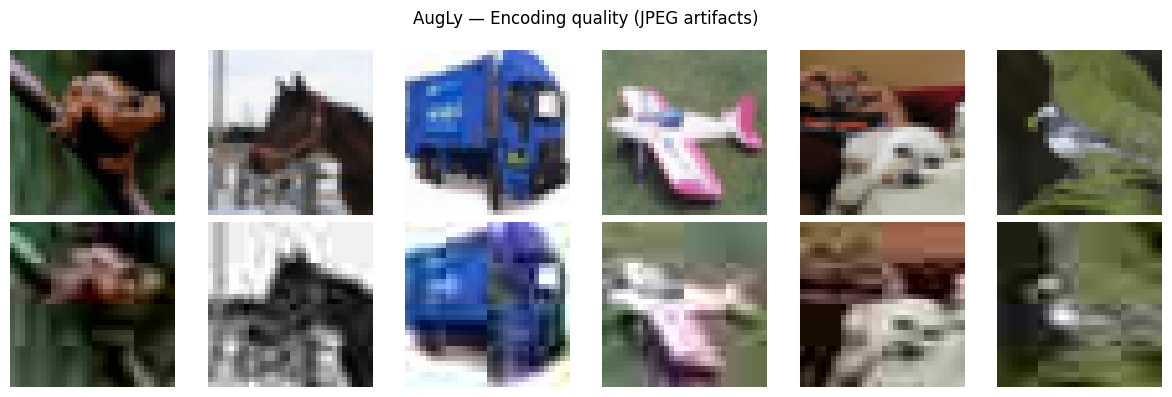

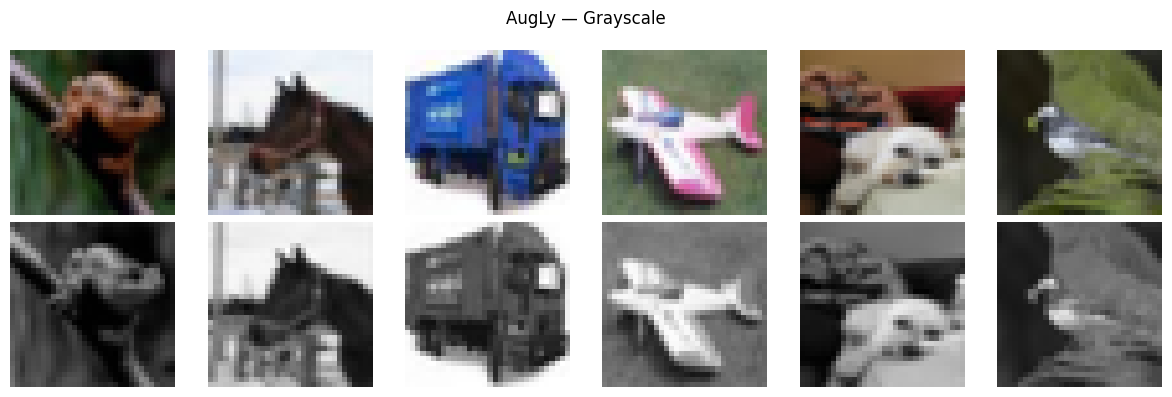

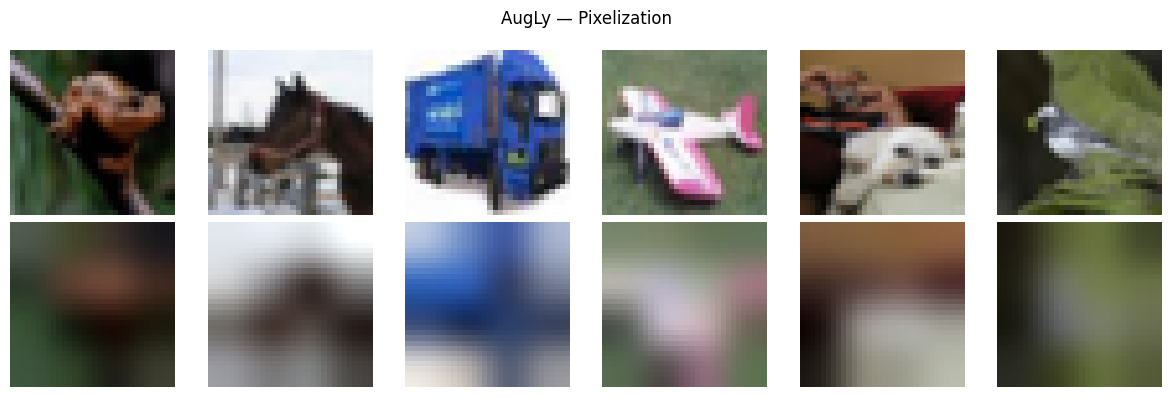


Note: AugLy perspective_transform is incompatible with NumPy >= 1.24
      (uses deprecated np.float alias removed in NumPy 1.24).
      Use albumentations A.Perspective() as a drop-in replacement:



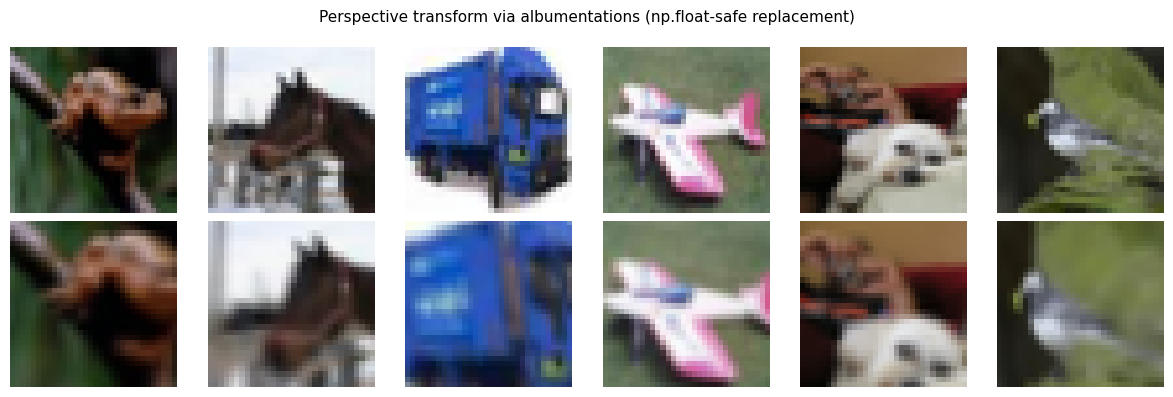

AugLy demos complete.


In [17]:
try:
    import augly.image as imaugs
    from PIL import Image
    AUGLY_AVAILABLE = True
    print('AugLy available.')
except ImportError:
    AUGLY_AVAILABLE = False
    print('AugLy not installed. Run: pip install augly')

if AUGLY_AVAILABLE:
    def apply_augly(aug_fn, images, n=6, title='AugLy'):
        """
        Apply an AugLy transform to n images and display before/after.
        AugLy works with PIL Images.
        """
        fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
        for i in range(n):
            axes[0, i].imshow(images[i])
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_ylabel('Original', fontsize=9)

            try:
                pil_img  = Image.fromarray(images[i])
                aug_pil  = aug_fn(pil_img)
                axes[1, i].imshow(np.array(aug_pil))
            except Exception as e:
                # If an AugLy function fails due to numpy version
                # incompatibility, show original with error label
                axes[1, i].imshow(images[i])
                axes[1, i].set_title(f'Error: {str(e)[:30]}', fontsize=6, color='red')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_ylabel('AugLy', fontsize=9)

        plt.suptitle(title, fontsize=12)
        plt.tight_layout()
        plt.show()

    # --- Blur ---
    apply_augly(
        lambda img: imaugs.blur(img, radius=2.0),
        X_train, title='AugLy — Blur'
    )

    # --- Encoding quality degradation ---
    apply_augly(
        lambda img: imaugs.encoding_quality(img, quality=15),
        X_train, title='AugLy — Encoding quality (JPEG artifacts)'
    )

    # --- Grayscale ---
    apply_augly(
        lambda img: imaugs.grayscale(img),
        X_train, title='AugLy — Grayscale'
    )

    # --- Pixelization ---
    apply_augly(
        lambda img: imaugs.pixelization(img, ratio=0.15),
        X_train, title='AugLy — Pixelization'
    )

    # --- Meme format (adds caption bar) ---
    # perspective_transform is SKIPPED — it uses np.float which was
    # removed in NumPy 1.24. Use albumentations Perspective instead.
    print()
    print('Note: AugLy perspective_transform is incompatible with NumPy >= 1.24')
    print('      (uses deprecated np.float alias removed in NumPy 1.24).')
    print('      Use albumentations A.Perspective() as a drop-in replacement:')
    print()

    # Albumentations Perspective as the fix
    import albumentations as A
    import cv2
    persp_aug = A.Compose([A.Perspective(scale=(0.05, 0.12), p=1.0)])

    fig, axes = plt.subplots(2, 6, figsize=(12, 4))
    for i in range(6):
        axes[0, i].imshow(X_train[i])
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('Original', fontsize=9)

        result = persp_aug(image=X_train[i])
        axes[1, i].imshow(result['image'])
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('A.Perspective\n(replaces AugLy)', fontsize=8)
    plt.suptitle('Perspective transform via albumentations (np.float-safe replacement)', fontsize=11)
    plt.tight_layout()
    plt.show()

    print('AugLy demos complete.')
else:
    print('Skipping AugLy demo — library not available.')


## 9. PyTorch Dataset with Albumentations

The correct pattern: wrap albumentations in a PyTorch `Dataset`.
The transform runs in `__getitem__` on CPU, then the DataLoader
batches results and moves them to GPU.


In [18]:
class CIFAR10Albumentations(Dataset):
    """
    PyTorch Dataset that applies albumentations transforms.

    The transform pipeline is passed in — use TRAIN_TRANSFORM for training
    and VAL_TRANSFORM for validation/test (no augmentation at inference).
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images    # uint8 numpy (N, 32, 32, 3)
        self.labels    = labels    # int numpy (N,)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].copy()   # albumentations modifies in-place
        label = int(self.labels[idx])

        if self.transform:
            result = self.transform(image=image)   # albumentations API
            image  = result['image']

        # Convert uint8 HWC numpy -> float32 CHW tensor normalised to [0,1]
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        return image, label


# Validation transform: only normalise, no augmentation
VAL_TRANSFORM = A.Compose([])

BATCH_SIZE = 64

train_dataset_aug   = CIFAR10Albumentations(X_train, y_train, transform=TRAIN_TRANSFORM)
train_dataset_noaug = CIFAR10Albumentations(X_train, y_train, transform=VAL_TRANSFORM)
valid_dataset       = CIFAR10Albumentations(X_valid, y_valid, transform=VAL_TRANSFORM)
test_dataset        = CIFAR10Albumentations(X_test,  y_test,  transform=VAL_TRANSFORM)

train_loader_aug   = DataLoader(train_dataset_aug,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader       = DataLoader(valid_dataset,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader        = DataLoader(test_dataset,         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader_aug)}')
print(f'Valid batches: {len(valid_loader)}')

# Verify a batch
X_b, y_b = next(iter(train_loader_aug))
print(f'Batch shape: {X_b.shape}, dtype: {X_b.dtype}, range: [{X_b.min():.2f}, {X_b.max():.2f}]')

Train batches: 704
Valid batches: 79
Batch shape: torch.Size([64, 3, 32, 32]), dtype: torch.float32, range: [0.00, 1.00]


## 10. CNN Classifier


In [19]:
class SimpleCNN(nn.Module):
    """
    Small CNN for CIFAR-10 classification.
    Input: (batch, 3, 32, 32) float32 in [0, 1]
    Output: (batch, 10) logits
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.4),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

test_cnn = SimpleCNN().to(device)
print(f'Total parameters: {count_params(test_cnn):,}')

dummy = torch.zeros(4, 3, 32, 32).to(device)
print(f'Output shape: {test_cnn(dummy).shape}  (expect [4, 10])')

Total parameters: 323,498
Output shape: torch.Size([4, 10])  (expect [4, 10])


## 11. Training Loop


In [20]:
def train_model(train_loader, epochs=25, label=''):
    torch.manual_seed(42)
    model     = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_weights = None
    hist = {'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            correct += (model(X_b).detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
        train_acc = correct / total

        # Validation
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc = correct / total

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | train={train_acc:.4f} | val={val_acc:.4f}')

    # Restore best weights and evaluate on test set
    model.load_state_dict(best_weights)
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            correct += (model(X_b).argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
    test_acc = correct / total
    print(f'[{label}] Test accuracy: {test_acc:.4f}\n')
    return hist, test_acc, model


print('Training model WITHOUT augmentation...')
hist_noaug, test_acc_noaug, model_noaug = train_model(
    train_loader_noaug, epochs=25, label='No aug'
)

print('Training model WITH augmentation pipeline...')
hist_aug, test_acc_aug, model_aug = train_model(
    train_loader_aug, epochs=25, label='Augmented'
)

Training model WITHOUT augmentation...
[No aug] Epoch  5 | train=0.6172 | val=0.6784
[No aug] Epoch 10 | train=0.7075 | val=0.7510
[No aug] Epoch 15 | train=0.7652 | val=0.8108
[No aug] Epoch 20 | train=0.7970 | val=0.8306
[No aug] Epoch 25 | train=0.8116 | val=0.8342
[No aug] Test accuracy: 0.8226

Training model WITH augmentation pipeline...
[Augmented] Epoch  5 | train=0.4790 | val=0.6038
[Augmented] Epoch 10 | train=0.5698 | val=0.6998
[Augmented] Epoch 15 | train=0.6155 | val=0.7486
[Augmented] Epoch 20 | train=0.6504 | val=0.7768
[Augmented] Epoch 25 | train=0.6544 | val=0.7852
[Augmented] Test accuracy: 0.7751



## 12. A/B Test Results


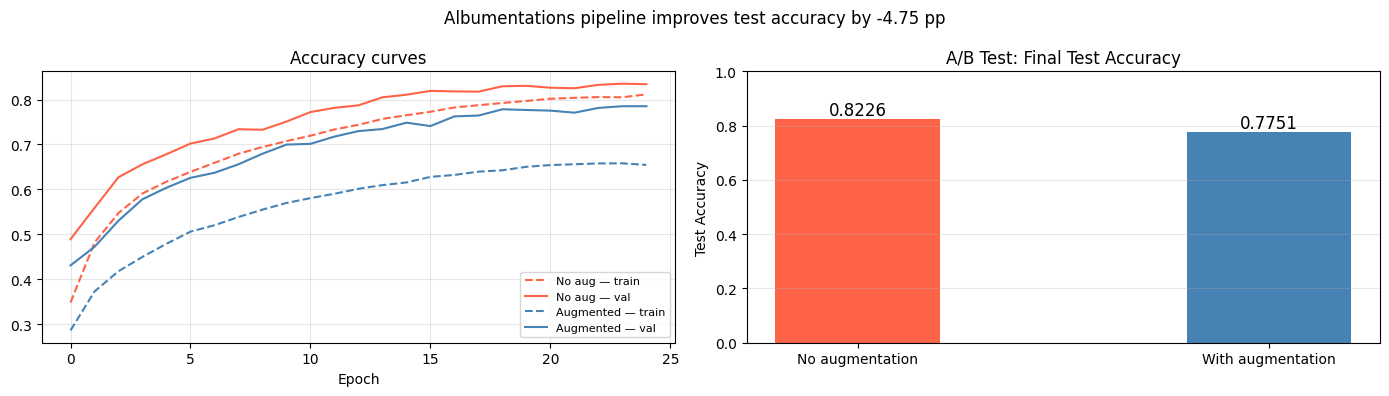

No augmentation  test accuracy: 0.8226
With augmentation test accuracy: 0.7751
Improvement: -4.75 percentage points


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_noaug['train_acc'], '--', color='tomato',    label='No aug — train')
axes[0].plot(hist_noaug['val_acc'],         color='tomato',    label='No aug — val')
axes[0].plot(hist_aug['train_acc'],   '--', color='steelblue', label='Augmented — train')
axes[0].plot(hist_aug['val_acc'],           color='steelblue', label='Augmented — val')
axes[0].set_title('Accuracy curves')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar chart of test accuracy
bars = axes[1].bar(
    ['No augmentation', 'With augmentation'],
    [test_acc_noaug, test_acc_aug],
    color=['tomato', 'steelblue'],
    width=0.4
)
for bar, acc in zip(bars, [test_acc_noaug, test_acc_aug]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('A/B Test: Final Test Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Albumentations pipeline improves test accuracy by '
    f'{(test_acc_aug - test_acc_noaug)*100:.2f} pp',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f'No augmentation  test accuracy: {test_acc_noaug:.4f}')
print(f'With augmentation test accuracy: {test_acc_aug:.4f}')
print(f'Improvement: {(test_acc_aug - test_acc_noaug)*100:.2f} percentage points')

## 13. Per-Class Accuracy Analysis


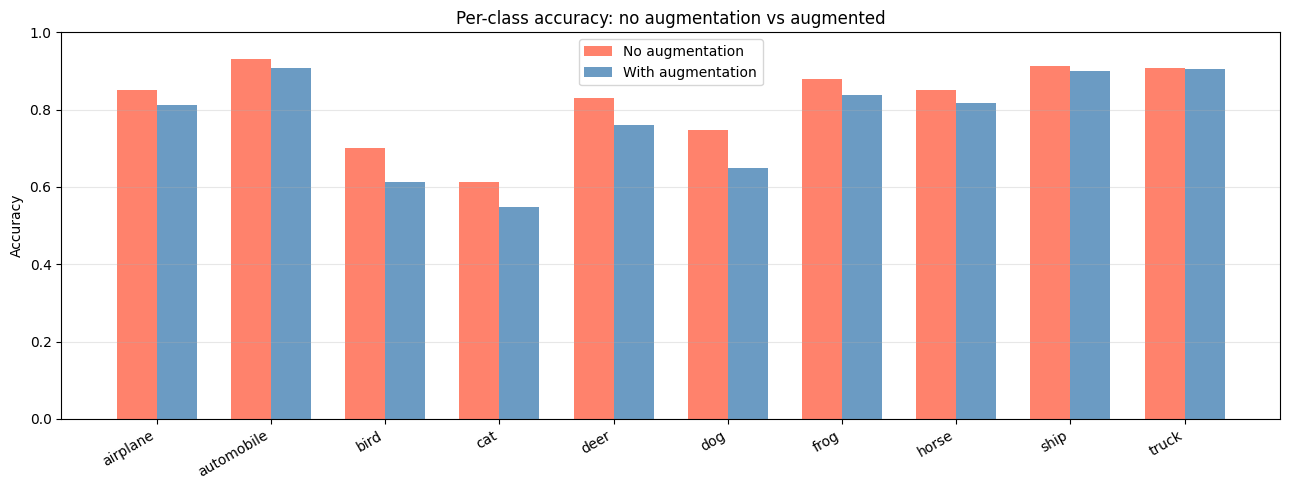

Per-class improvement:
  airplane    : 0.852 -> 0.812  (-4.0 pp)
  automobile  : 0.932 -> 0.908  (-2.4 pp)
  bird        : 0.701 -> 0.613  (-8.8 pp)
  cat         : 0.612 -> 0.549  (-6.3 pp)
  deer        : 0.831 -> 0.759  (-7.2 pp)
  dog         : 0.748 -> 0.650  (-9.8 pp)
  frog        : 0.880 -> 0.838  (-4.2 pp)
  horse       : 0.850 -> 0.817  (-3.3 pp)
  ship        : 0.912 -> 0.901  (-1.1 pp)
  truck       : 0.908 -> 0.904  (-0.4 pp)


In [22]:
def per_class_accuracy(model, loader):
    """Compute accuracy for each class separately."""
    model.eval()
    class_correct = np.zeros(10)
    class_total   = np.zeros(10)
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds = model(X_b).argmax(1)
            for cls in range(10):
                mask = (y_b == cls)
                class_correct[cls] += (preds[mask] == y_b[mask]).sum().item()
                class_total[cls]   += mask.sum().item()
    return class_correct / np.maximum(class_total, 1)


acc_noaug_per_class = per_class_accuracy(model_noaug, test_loader)
acc_aug_per_class   = per_class_accuracy(model_aug,   test_loader)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, acc_noaug_per_class, width, label='No augmentation', color='tomato',    alpha=0.8)
bars2 = ax.bar(x + width/2, acc_aug_per_class,   width, label='With augmentation', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title('Per-class accuracy: no augmentation vs augmented')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Per-class improvement:')
for i, cls in enumerate(CLASS_NAMES):
    diff = acc_aug_per_class[i] - acc_noaug_per_class[i]
    sign = '+' if diff >= 0 else ''
    print(f'  {cls:12s}: {acc_noaug_per_class[i]:.3f} -> {acc_aug_per_class[i]:.3f}  ({sign}{diff*100:.1f} pp)')

---
## Summary

### Albumentations API Pattern
```python
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.HueSaturationValue(),
        A.RandomBrightnessContrast(),
    ], p=0.6),
    A.GaussNoise(p=0.2),
    A.CoarseDropout(max_holes=2, p=0.3),
])

result = transform(image=img_uint8)   # always keyword argument
aug_img = result['image']             # uint8 numpy HxWxC
```

### Transform Selection Guide

| Goal | Transforms |
|---|---|
| Position invariance | `HorizontalFlip`, `ShiftScaleRotate`, `RandomCrop` |
| Lighting invariance | `RandomBrightnessContrast`, `HueSaturationValue`, `CLAHE` |
| Noise robustness | `GaussNoise`, `MotionBlur`, `ImageCompression` |
| Occlusion robustness | `CoarseDropout`, `GridDistortion` |
| Geometry invariance | `Perspective`, `ElasticTransform` |
| Domain shift | `ChannelShuffle`, `ToGray`, AugLy overlays |

**Next: Notebook 10** — Video augmentation
